## Flight Database

In [2]:
import os
import glob 
import numpy as np
import pandas as pd
import math
import pilot_tools as pt
import matplotlib.pyplot as plt

MAIN_DIR = os.getcwd()
DATA_DIR = os.path.join(MAIN_DIR, "DATA")
BACKUP_DIR = os.path.join(DATA_DIR, "PILOTS_BACKUP")

In [ ]:
def plot_flight_path(test_folder):
    flight_xls = sorted(glob.glob(os.path.join(test_folder, "*.xlsx")))
    
    def haversine_m(lat1, lon1, lat2, lon2):
        R = 6371000  # Earth radius (m)
        phi1, phi2 = math.radians(lat1), math.radians(lat2)
        dphi = math.radians(lat2 - lat1)
        dlambda = math.radians(lon2 - lon1)
        x = R * dlambda * math.cos((phi1 + phi2) / 2)
        y = R * dphi
        return x, y

    for file in flight_xls:
        gps = pt.get_gps(file)  # Replace with your GPS reading function
        df = pd.DataFrame(gps, columns=["Lat", "Lng"])

        ref_lat, ref_lon = df['Lat'].iloc[0], df['Lng'].iloc[0]
        x_m, y_m = [], []
        for lat, lon in zip(df['Lat'], df['Lng']):
            xm, ym = haversine_m(ref_lat, ref_lon, lat, lon)
            x_m.append(xm)
            y_m.append(ym)

        x_m, y_m = np.array(x_m), np.array(y_m)

        # --- Plot flight path ---
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.plot(x_m, y_m, color='blue', linewidth=2)
        ax.set_title(f'Flight: {os.path.basename(file)}')
        ax.set_xlabel('East-West distance (m)')
        ax.set_ylabel('North-South distance (m)')
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True)
        plt.show()
        print(f"Flight Length: {len(gps)}")

# def plot_flight_path_one(file, title):
#     def haversine_m(lat1, lon1, lat2, lon2):
#         R = 6371000  # Earth radius (m)
#         phi1, phi2 = math.radians(lat1), math.radians(lat2)
#         dphi = math.radians(lat2 - lat1)
#         dlambda = math.radians(lon2 - lon1)
#         x = R * dlambda * math.cos((phi1 + phi2) / 2)
#         y = R * dphi
#         return x, y

#     gps = pt.get_gps(file)  # Replace with your GPS reading function
#     df = pd.DataFrame(gps, columns=["Lat", "Lng"])

#     ref_lat, ref_lon = df['Lat'].iloc[0], df['Lng'].iloc[0]
#     x_m, y_m = [], []
#     for lat, lon in zip(df['Lat'], df['Lng']):
#         xm, ym = haversine_m(ref_lat, ref_lon, lat, lon)
#         x_m.append(xm)
#         y_m.append(ym)

#     x_m, y_m = np.array(x_m), np.array(y_m)

#     # --- Plot flight path ---
#     fig, ax = plt.subplots(figsize=(8, 8))
#     ax.plot(x_m, y_m, color='blue', linewidth=2)
#     ax.set_title(title)
#     ax.set_xlabel('East-West distance (m)')
#     ax.set_ylabel('North-South distance (m)')
#     ax.set_aspect('equal', adjustable='box')
#     ax.grid(True)
#     plt.show()
#     print(f"Flight Length: {len(gps)}")

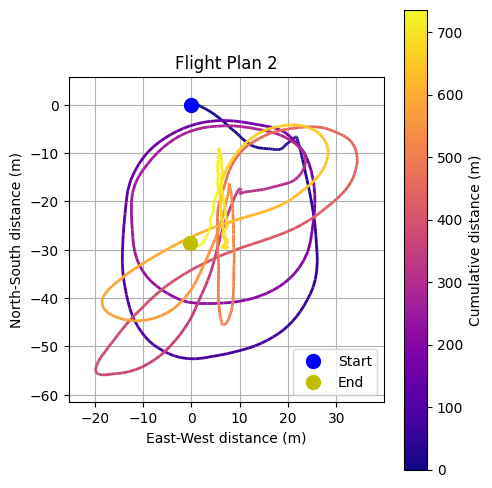

Flight Length: 791 | Total Distance: 735.8 m


In [21]:
def plot_flight_path_one(file, title):
    def haversine_m(lat1, lon1, lat2, lon2):
        R = 6371000
        phi1, phi2 = math.radians(lat1), math.radians(lat2)
        dphi = math.radians(lat2 - lat1)
        dlambda = math.radians(lon2 - lon1)
        x = R * dlambda * math.cos((phi1 + phi2) / 2)
        y = R * dphi
        return x, y

    gps = pt.get_gps(file)
    df = pd.DataFrame(gps, columns=["Lat", "Lng"])

    # Drop duplicate/stationary points and NaNs
    df = df.dropna().drop_duplicates()

    ref_lat, ref_lon = df['Lat'].iloc[0], df['Lng'].iloc[0]

    x_m, y_m = [], []
    for lat, lon in zip(df['Lat'], df['Lng']):
        xm, ym = haversine_m(ref_lat, ref_lon, lat, lon)
        x_m.append(xm)
        y_m.append(ym)

    x_m, y_m = np.array(x_m), np.array(y_m)

    # Compute cumulative distance
    dists = np.sqrt(np.diff(x_m)**2 + np.diff(y_m)**2)
    total_dist = np.sum(dists)
    cumulative = np.concatenate([[0], np.cumsum(dists)])

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(5, 5))

    # Color path by progress
    from matplotlib.collections import LineCollection
    points = np.array([x_m, y_m]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = plt.Normalize(cumulative.min(), cumulative.max())
    lc = LineCollection(segments, cmap='plasma', norm=norm, linewidth=2)
    lc.set_array(cumulative[:-1])
    ax.add_collection(lc)
    plt.colorbar(lc, ax=ax, label='Cumulative distance (m)')

    # Mark start and end
    ax.plot(x_m[0], y_m[0], 'bo', markersize=10, label='Start', zorder=5)
    ax.plot(x_m[-1], y_m[-1], 'yo', markersize=10, label='End', zorder=5)

    # Bounding box padding
    pad = max((x_m.max() - x_m.min()), (y_m.max() - y_m.min())) * 0.1 or 1
    ax.set_xlim(x_m.min() - pad, x_m.max() + pad)
    ax.set_ylim(y_m.min() - pad, y_m.max() + pad)

    ax.set_title(title)
    ax.set_xlabel('East-West distance (m)')
    ax.set_ylabel('North-South distance (m)')
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='lower right')
    ax.grid(True)

    plt.tight_layout()
    plt.show()
    print(f"Flight Length: {len(gps)} | Total Distance: {total_dist:.1f} m")

flight = "DATA\PILOTS_BACKUP\LUKE\clip128G_LF_AA_L.xlsx"
plot_flight_path_one(flight,"Flight Plan 2")

Availiable pilots:
(1) = BILLY
(2) = DREW
(3) = flights.csv
(4) = JACOB
(5) = JUSTIN
(6) = LUKE
c:\Users\micah\Documents\FENNEC\FENNEC-25_26\Micah_Yarbrough\DATA\PILOTS_BACKUP\LUKE


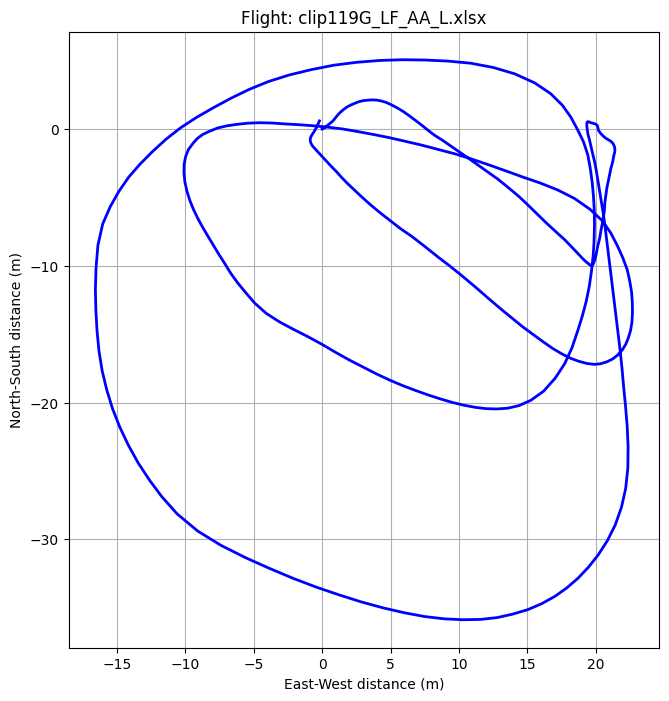

Flight Length: 372


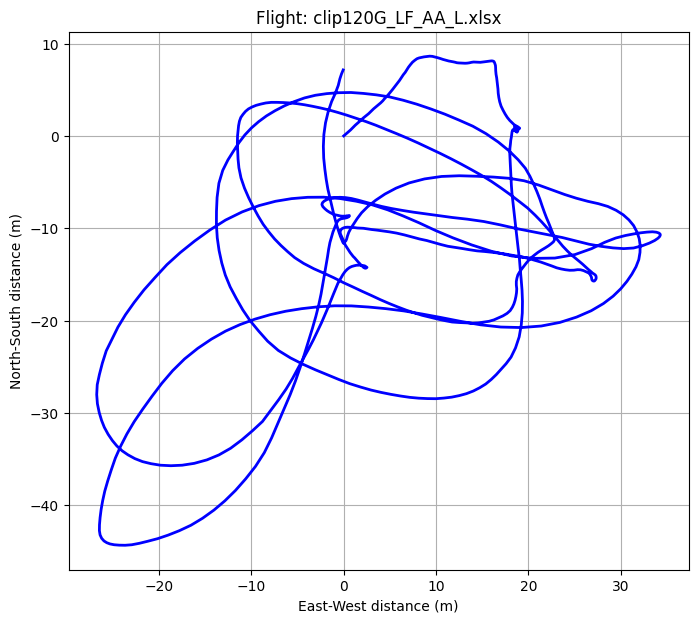

Flight Length: 790


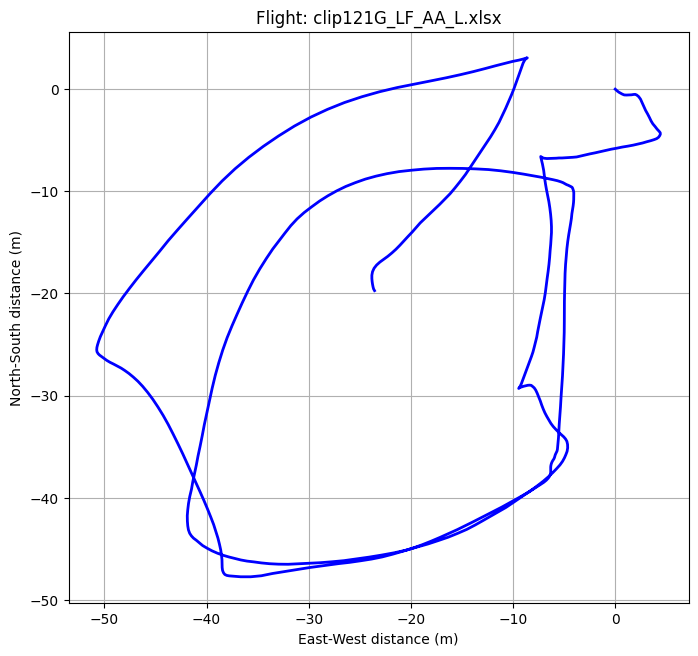

Flight Length: 511


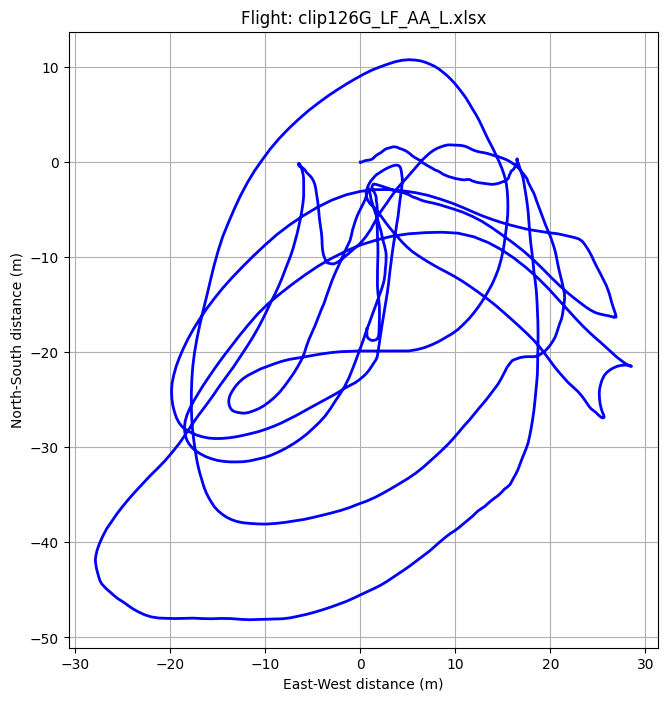

Flight Length: 1114


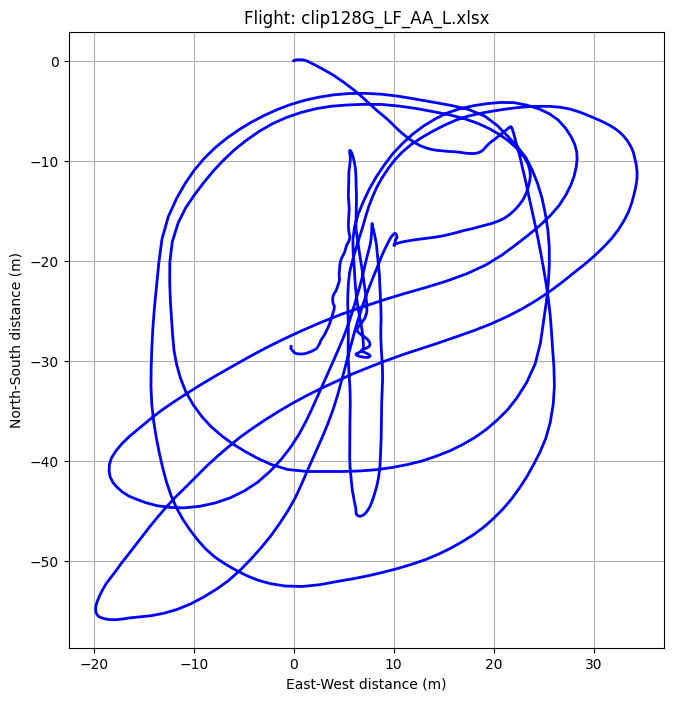

Flight Length: 791


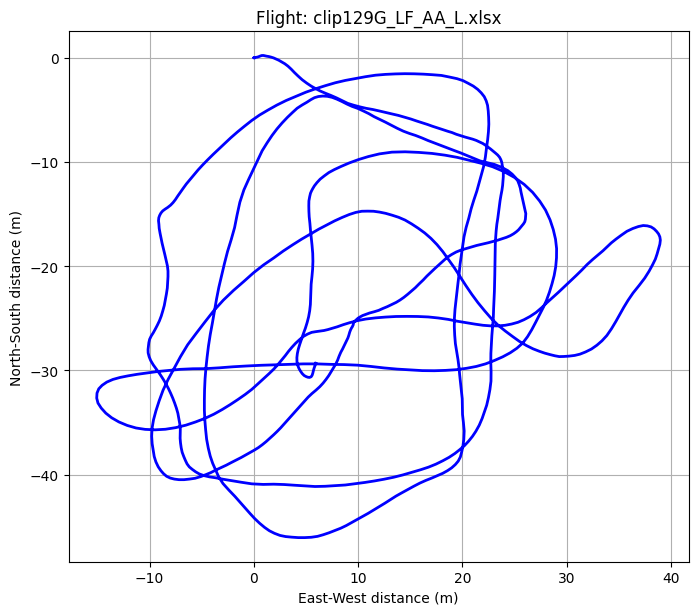

Flight Length: 852


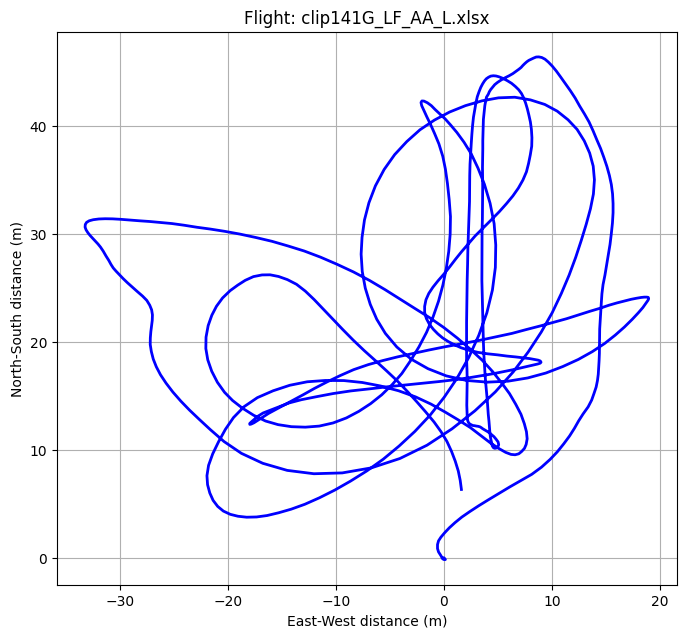

Flight Length: 683


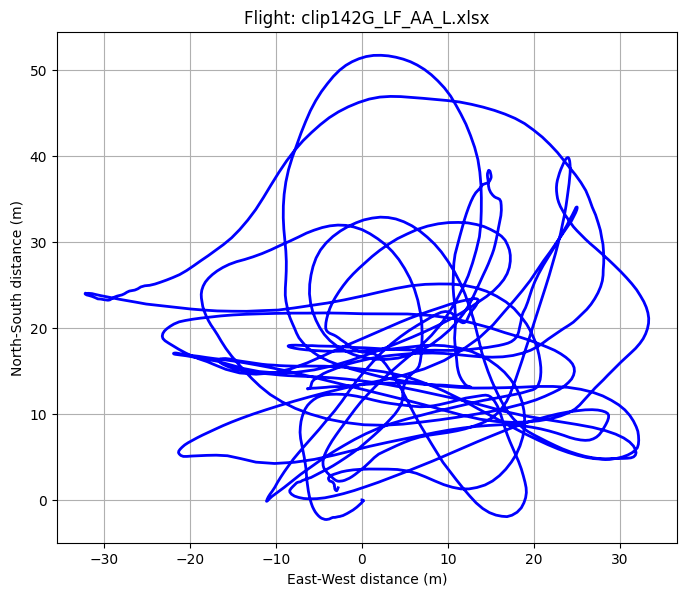

Flight Length: 1636


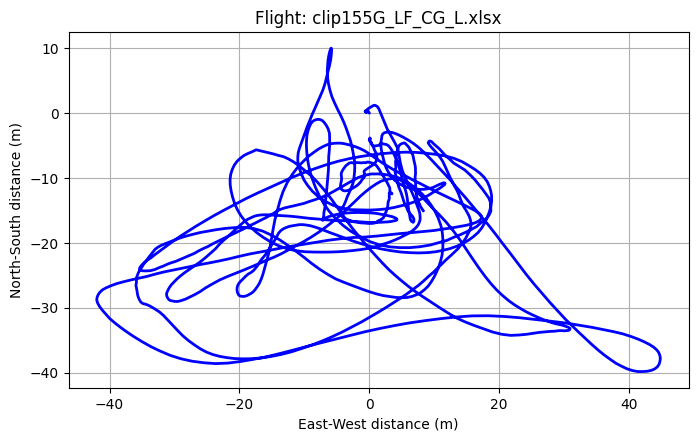

Flight Length: 1581


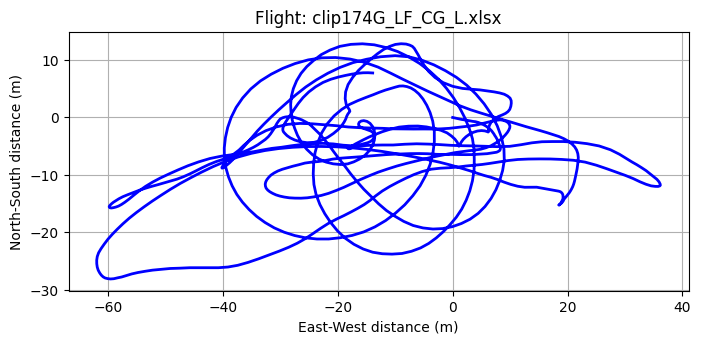

Flight Length: 842


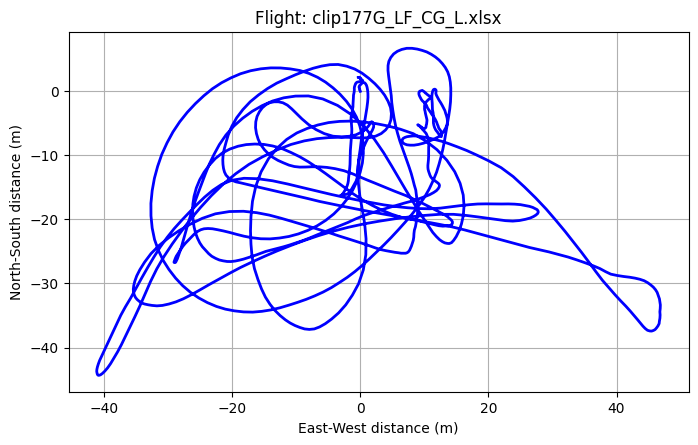

Flight Length: 1317


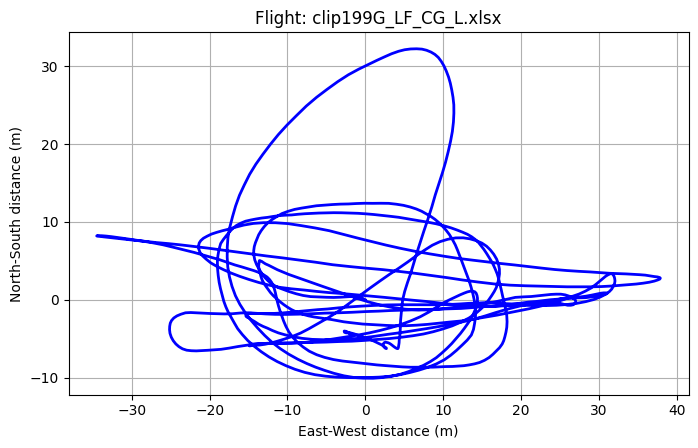

Flight Length: 977


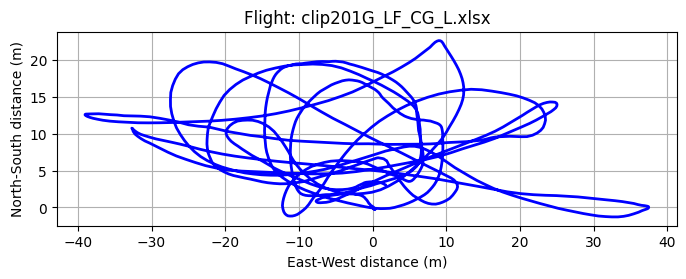

Flight Length: 1029


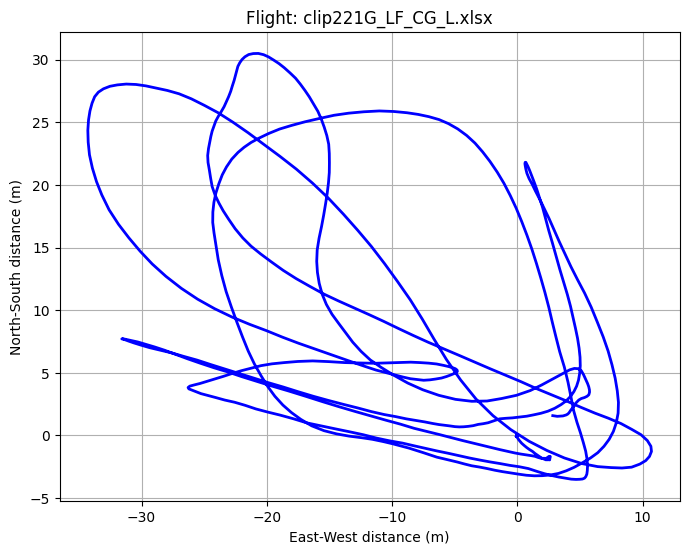

Flight Length: 679


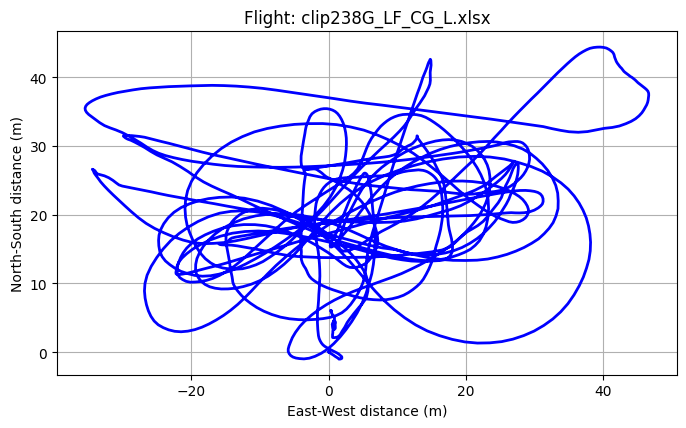

Flight Length: 2196


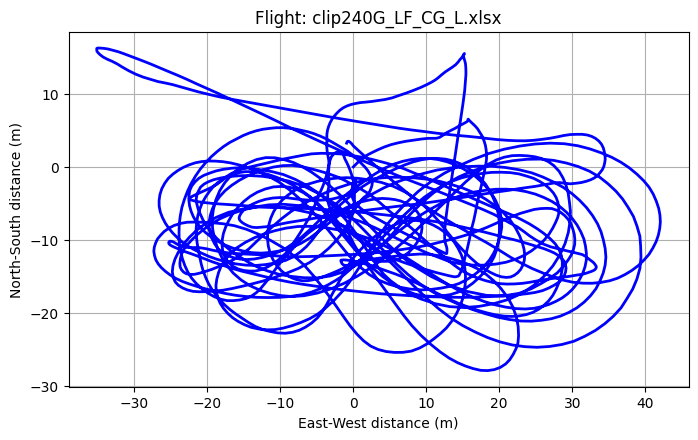

Flight Length: 2011


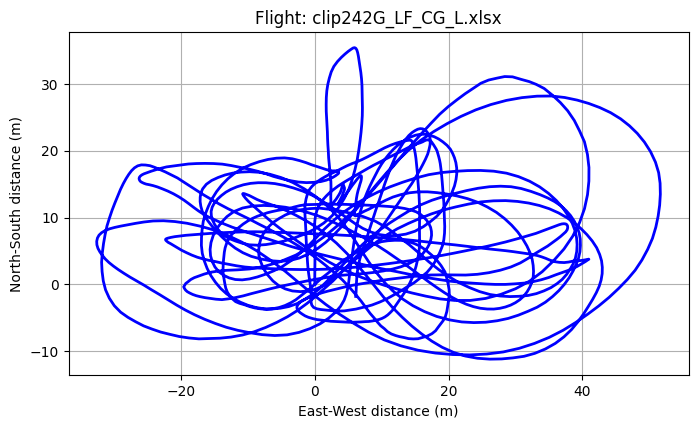

Flight Length: 1591


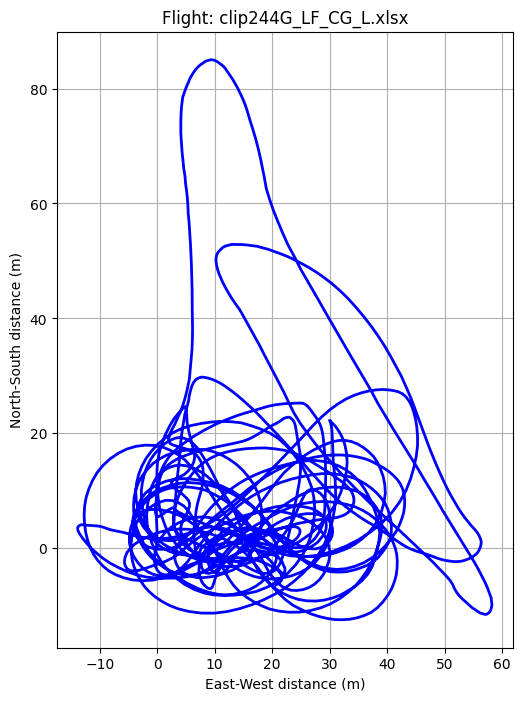

Flight Length: 2003


In [ ]:
choice = int(input("View a flight (1)\nView all a pilot's flights (2)"))
pilots = os.listdir(BACKUP_DIR)
if choice == 2:
    print("Availiable pilots:")
    for i in range(len(pilots)):
        print(f"({i+1}) = {pilots[i]}")
    choice = int(input("Pick a Pilot -->"))
    pilot_path = os.path.join(BACKUP_DIR, pilots[choice-1])
    print(pilot_path)
    plot_flight_path(pilot_path)
